In [1]:
import os
import re
from collections import defaultdict
from typing import List, Dict, Tuple, Set
import multiprocessing as mp
from functools import partial
from tqdm import tqdm

def process_file(file_name: str, directory: str, ignore_list: List[str], pattern: re.Pattern) -> Tuple[str, str, str]:
    full_path = os.path.join(directory, file_name)
    if not os.path.isfile(full_path) or (ignore_list and any(ignore_text in file_name for ignore_text in ignore_list)):
        return None
    name, ext = os.path.splitext(file_name)
    modified_name = pattern.sub(r'\1\2', name)
    return (modified_name, ext, full_path)

def analyze_files(directory: str, ignore_list: List[str] = None, num_processes: int = None) -> Dict[str, Tuple[int, List[str], Set[str]]]:
    num_processes = mp.cpu_count() if num_processes is None else num_processes

    pattern = re.compile(r'(.*?)[0-9]{6}(.*)')
    
    file_list = os.listdir(directory)
    
    with mp.Pool(processes=num_processes) as pool:
        process_func = partial(process_file, directory=directory, ignore_list=ignore_list, pattern=pattern)
        results = list(tqdm(pool.imap(process_func, file_list), total=len(file_list), desc="Analyzing files"))

    file_info = defaultdict(lambda: [0, set(), set()])
    for result in results:
        if result:
            modified_name, ext, full_path = result
            file_info[modified_name][0] += 1
            file_info[modified_name][1].add(ext)
            file_info[modified_name][2].add(full_path)

    return {k: (v[0], list(v[1]), v[2]) for k, v in file_info.items()}

In [2]:
directory = '/data-net/ted/H2/H2_1_1/'

file_analysis = analyze_files(directory, 
                              ignore_list=['flow', 'warped', 'overlay', '.tar', '.mp4', '_frame', 'AM_image'])

Analyzing files: 100%|██████████| 1236845/1236845 [00:43<00:00, 28424.23it/s]


In [21]:
for key, (count, extensions, paths) in file_analysis.items():
    print(f"File type: {key}")
    print(f"  Count: {count}")
    print(f"  Extensions: {extensions}")
    print(f"  Example paths:")
    for path in list(paths)[:3]:  # Print up to 3 example paths
        print(f"    {path}")
    print()

File type: rgb_CloudyNoon_central
  Count: 18354
  Extensions: ['.jpg']
  Example paths:
    /data-net/ted/H2/H2_1_1/rgb_CloudyNoon_central016233.jpg
    /data-net/ted/H2/H2_1_1/rgb_CloudyNoon_central000718.jpg
    /data-net/ted/H2/H2_1_1/rgb_CloudyNoon_central003388.jpg

File type: rgb_WetNoon_central
  Count: 18353
  Extensions: ['.jpg']
  Example paths:
    /data-net/ted/H2/H2_1_1/rgb_WetNoon_central004052.jpg
    /data-net/ted/H2/H2_1_1/rgb_WetNoon_central003195.jpg
    /data-net/ted/H2/H2_1_1/rgb_WetNoon_central000767.jpg

File type: attention_mirror_left
  Count: 18951
  Extensions: ['.npz']
  Example paths:
    /data-net/ted/H2/H2_1_1/attention_mirror_left008130.npz
    /data-net/ted/H2/H2_1_1/attention_mirror_left008595.npz
    /data-net/ted/H2/H2_1_1/attention_mirror_left009516.npz

File type: rgb_left
  Count: 18290
  Extensions: ['.jpg']
  Example paths:
    /data-net/ted/H2/H2_1_1/rgb_left007130.jpg
    /data-net/ted/H2/H2_1_1/rgb_left015341.jpg
    /data-net/ted/H2/H2_1_1/

## Get the Averages and number of samples

In [3]:
import os
import numpy as np
from PIL import Image
from PIL import ImageFile
import multiprocessing as mp
from functools import partial
from typing import Dict, List, Tuple, Any, Set
from tqdm import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

def load_and_process_file(file_path: str, file_type: str) -> np.ndarray:
    if file_type.startswith('rgb') or file_type.startswith('semantic') or file_type.startswith('depth'):
        return np.array(Image.open(file_path))
    elif file_type.startswith('attention'):
        with np.load(file_path) as data:
            return data['attention']
    else:
        raise ValueError(f"Unsupported file type: {file_type}")

def compute_average(file_paths: List[str], file_type: str) -> Tuple[np.ndarray, int]:
    with mp.Pool() as pool:
        process_func = partial(load_and_process_file, file_type=file_type)
        data_list = list(tqdm(pool.imap(process_func, file_paths), 
                              total=len(file_paths), 
                              desc=f"Processing {file_type}"))
    
    data_array = np.stack(data_list)
    average_data = np.mean(data_array, axis=0)
    
    if file_type.startswith('attention'):
        average_data = average_data / (np.sum(average_data) + 1e-8)
    elif file_type.startswith('rgb'):
        average_data = average_data.astype(np.uint8)
    
    return average_data, len(file_paths)

def compute_averages(file_info: Dict[str, Tuple[int, List[str], Set[str]]]) -> Dict[str, Tuple[int, np.ndarray, str]]:
    averages = {}
    
    for file_type, (count, extensions, paths) in tqdm(file_info.items(), desc="Computing averages"):
        if len(paths) == 0:
            continue
        
        file_paths = list(paths)
        extension = extensions[0] if extensions else ''
        
        try:
            average_data, num_files = compute_average(file_paths, file_type)
            averages[file_type] = (num_files, average_data, extension)
        except ValueError as e:
            print(f"Skipping {file_type}: {str(e)}")
    
    return averages

In [4]:
# Assuming we have the file_info dictionary from the previous analyze_files function
averages = compute_averages(file_analysis)

Computing averages:  28%|██▊       | 13/46 [29:39<1:15:12, 136.75s/it]

Skipping cmd_fix_can_bus: Unsupported file type: cmd_fix_can_bus


Computing averages: 100%|██████████| 46/46 [3:08:46<00:00, 246.24s/it]


File type: rgb_CloudyNoon_central
  Count: 18354
  Extension: .jpg
  Average data shape: (540, 960, 3)

File type: rgb_WetNoon_central
  Count: 18353
  Extension: .jpg
  Average data shape: (540, 960, 3)

File type: attention_mirror_left
  Count: 18951
  Extension: .npz
  Average data shape: (360, 640)

File type: rgb_left
  Count: 18290
  Extension: .jpg
  Average data shape: (540, 960, 3)

File type: semantic_segmentation_right
  Count: 18290
  Extension: .png
  Average data shape: (540, 960, 3)

File type: rgb_central
  Count: 18291
  Extension: .jpg
  Average data shape: (540, 960, 3)

File type: rgb_HardRainNoon_central
  Count: 18354
  Extension: .jpg
  Average data shape: (540, 960, 3)

File type: rgb_ClearSunset_left
  Count: 18331
  Extension: .jpg
  Average data shape: (540, 960, 3)

File type: depth_mirror_right
  Count: 18290
  Extension: .png
  Average data shape: (360, 640, 3)

File type: rgb_MidRainSunset_mirror_left
  Count: 18353
  Extension: .jpg
  Average data shape:

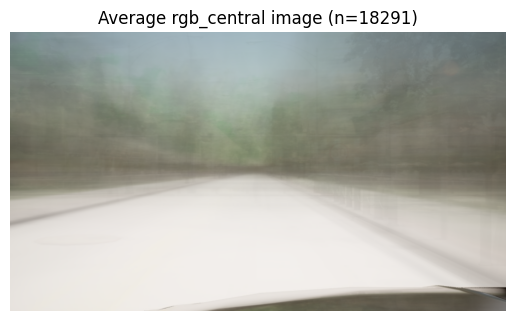

In [5]:
# Example of how to use the results
for file_type, (count, avg_data, ext) in averages.items():
    print(f"File type: {file_type}")
    print(f"  Count: {count}")
    print(f"  Extension: {ext}")
    print(f"  Average data shape: {avg_data.shape}")
    print()

# If you want to visualize an RGB image:
import matplotlib.pyplot as plt

if 'rgb_CloudyNoon_central' in averages:
    plt.imshow(averages['rgb_CloudyNoon_central'][1])
    plt.title(f"Average rgb_central image (n={averages['rgb_CloudyNoon_central'][0]})")
    plt.axis('off')
    plt.show()

In [13]:
import os
import numpy as np
from PIL import Image
import json
from tqdm import tqdm

def save_averages(averages: Dict[str, Tuple[int, np.ndarray, str]], output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    
    metadata = {}
    
    for file_type, (count, avg_data, ext) in tqdm(averages.items(), desc="Saving averages"):
        file_name = f"avg_{file_type}"
        metadata[file_type] = {"count": count, "extension": ext}
        
        if file_type.startswith('rgb'):
            # Save RGB image data
            img = Image.fromarray(avg_data.astype(np.uint8))
            img.save(os.path.join(output_dir, f"{file_name}.png"))
            metadata[file_type]["saved_as"] = f"{file_name}.png"
        
        elif file_type.startswith('semantic'):
            # Save semantic segmentation data
            img = Image.fromarray(avg_data.astype(np.uint8))
            img.save(os.path.join(output_dir, f"{file_name}.png"))
            metadata[file_type]["saved_as"] = f"{file_name}.png"
        
        elif file_type.startswith('depth'):
            # Handle depth data
            depth_min = np.min(avg_data)
            depth_max = np.max(avg_data)
            depth_normalized = (avg_data - depth_min) / (depth_max - depth_min)
            
            if avg_data.ndim == 2 or (avg_data.ndim == 3 and avg_data.shape[2] == 1):
                # Single-channel depth
                depth_uint16 = (depth_normalized * 65535).astype(np.uint16)
                if depth_uint16.ndim == 3:
                    depth_uint16 = depth_uint16[:,:,0]  # Remove singleton dimension if present
                img = Image.fromarray(depth_uint16)
                img.save(os.path.join(output_dir, f"{file_name}.png"))
            elif avg_data.ndim == 3 and avg_data.shape[2] == 3:
                # Multi-channel depth (treat as RGB)
                depth_uint8 = (depth_normalized * 255).astype(np.uint8)
                img = Image.fromarray(depth_uint8)
                img.save(os.path.join(output_dir, f"{file_name}.png"))
            else:
                # Unexpected shape, save as numpy array
                np.save(os.path.join(output_dir, f"{file_name}.npy"), avg_data)
                metadata[file_type]["saved_as"] = f"{file_name}.npy"
                print(f"Warning: Unexpected depth data shape for {file_type}. Saved as .npy file.")
            
            if "saved_as" not in metadata[file_type]:
                metadata[file_type]["saved_as"] = f"{file_name}.png"
            metadata[file_type]["depth_min"] = float(depth_min)
            metadata[file_type]["depth_max"] = float(depth_max)
        
        elif file_type.startswith('attention'):
            # Save attention data as npz file
            np.savez_compressed(os.path.join(output_dir, f"{file_name}.npz"), attention=avg_data)
            metadata[file_type]["saved_as"] = f"{file_name}.npz"
        
        else:
            # For other types, save as numpy array
            np.save(os.path.join(output_dir, f"{file_name}.npy"), avg_data)
            metadata[file_type]["saved_as"] = f"{file_name}.npy"
        
        metadata[file_type]["shape"] = avg_data.shape
        metadata[file_type]["dtype"] = str(avg_data.dtype)
    
    # Save metadata
    with open(os.path.join(output_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Averages saved in {output_dir}")

In [14]:
save_averages(averages=averages, output_dir='/data/121-2/Experiments/dporres/TED/H2')

Saving averages: 100%|██████████| 45/45 [00:07<00:00,  6.38it/s]

Averages saved in /data/121-2/Experiments/dporres/TED/H2


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json
import os

def plot_average_images(output_dir: str, file_types: List[str], figsize=(20, 4)):
    # Load metadata
    with open(os.path.join(output_dir, "metadata.json"), "r") as f:
        metadata = json.load(f)
    
    # Determine number of rows and columns
    n_images = len(file_types)
    n_cols = min(5, n_images)  # Max 5 images per row
    n_rows = (n_images - 1) // n_cols + 1
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(figsize[0], figsize[1] * n_rows))
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    for i, file_type in enumerate(file_types):
        row = i // n_cols
        col = i % n_cols
        
        if file_type not in metadata:
            print(f"Warning: {file_type} not found in metadata")
            continue
        
        file_info = metadata[file_type]
        file_path = os.path.join(output_dir, file_info["saved_as"])
        
        if file_path.endswith('.png'):
            img = np.array(Image.open(file_path))
        elif file_path.endswith('.npy'):
            img = np.load(file_path)
        elif file_path.endswith('.npz'):
            with np.load(file_path) as data:
                img = data['attention']
        else:
            print(f"Warning: Unsupported file format for {file_type}")
            continue
        
        if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
            axs[row, col].imshow(img, cmap='hot', interpolation='nearest')
        else:
            axs[row, col].imshow(img)
        
        title = f'{file_type}\n({file_info["count"]} files, {img.shape[1]}x{img.shape[0]})'
        axs[row, col].set_title(title, fontsize=12)
        axs[row, col].axis('off')
    
    # Remove any unused subplots
    for i in range(n_images, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axs[row, col])
    
    plt.tight_layout()
    plt.show()

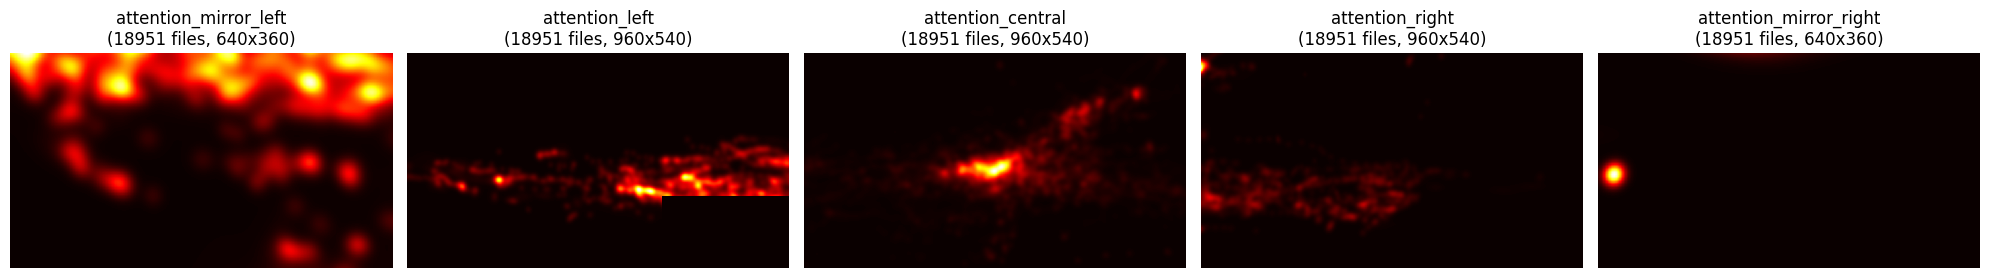

In [25]:
# Example usage:
output_dir = '/data/121-2/Experiments/dporres/TED/H2'
file_types_to_plot = ['attention_mirror_left', 'attention_left', 'attention_central', 'attention_right', 'attention_mirror_right']
plot_average_images(output_dir, file_types_to_plot)

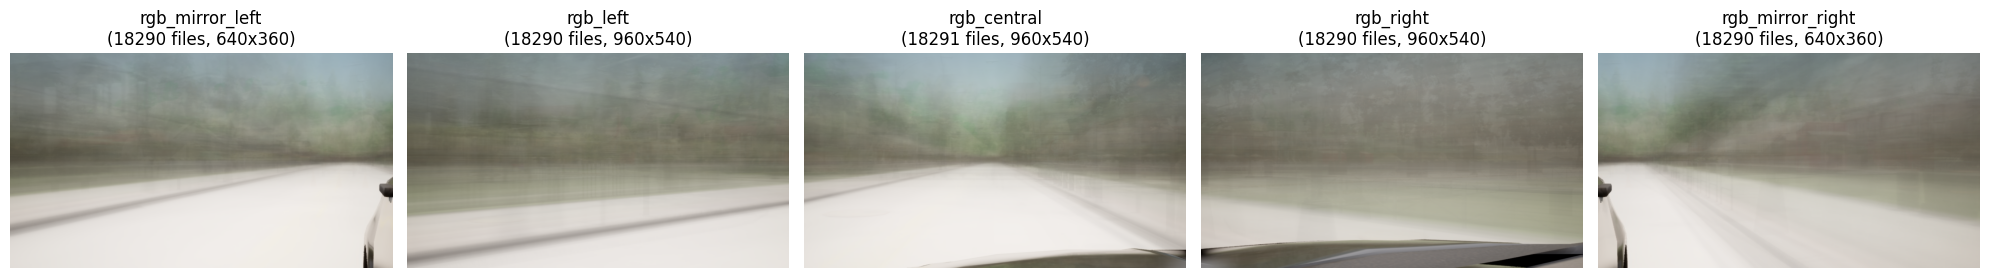

In [26]:
file_types_to_plot = ['rgb_mirror_left', 'rgb_left', 'rgb_central', 'rgb_right', 'rgb_mirror_right']
plot_average_images(output_dir, file_types_to_plot)

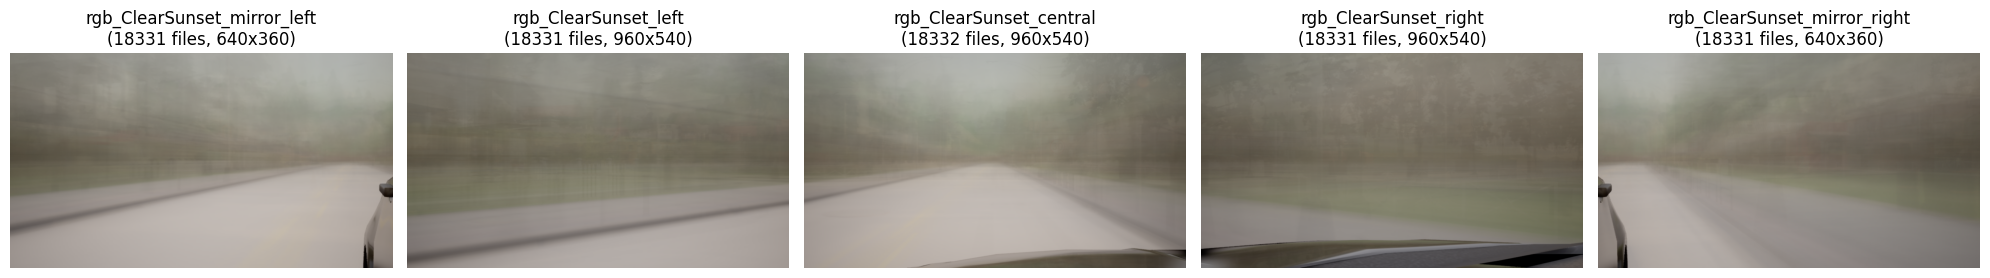

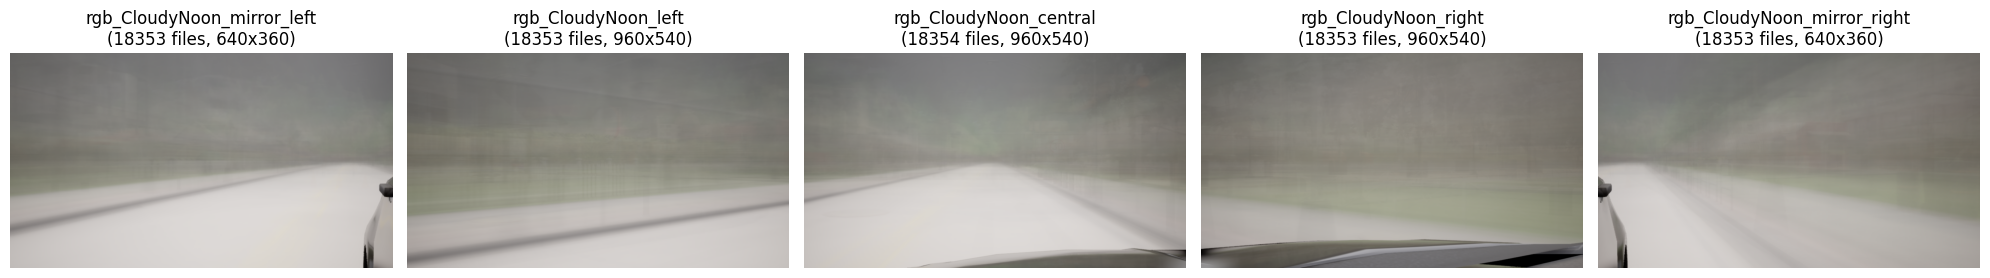

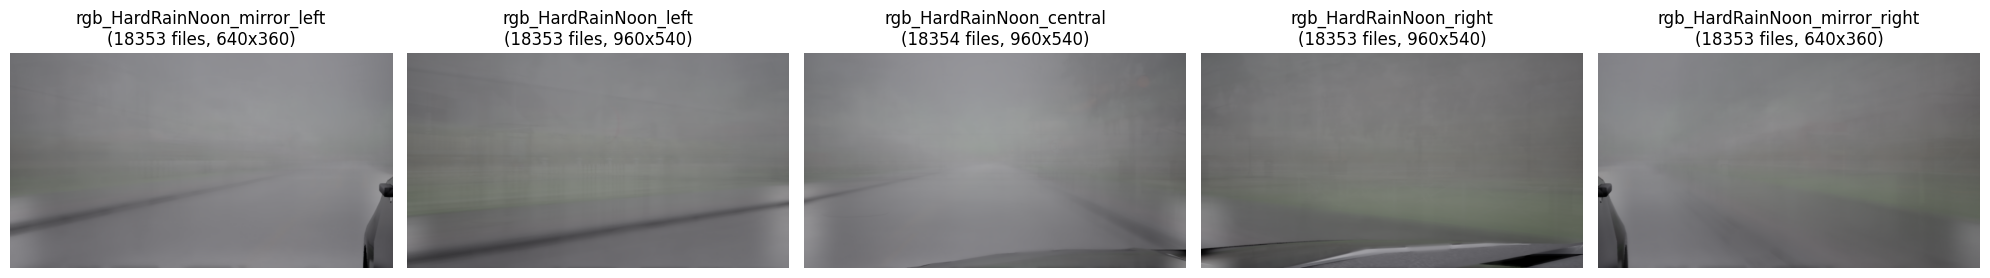

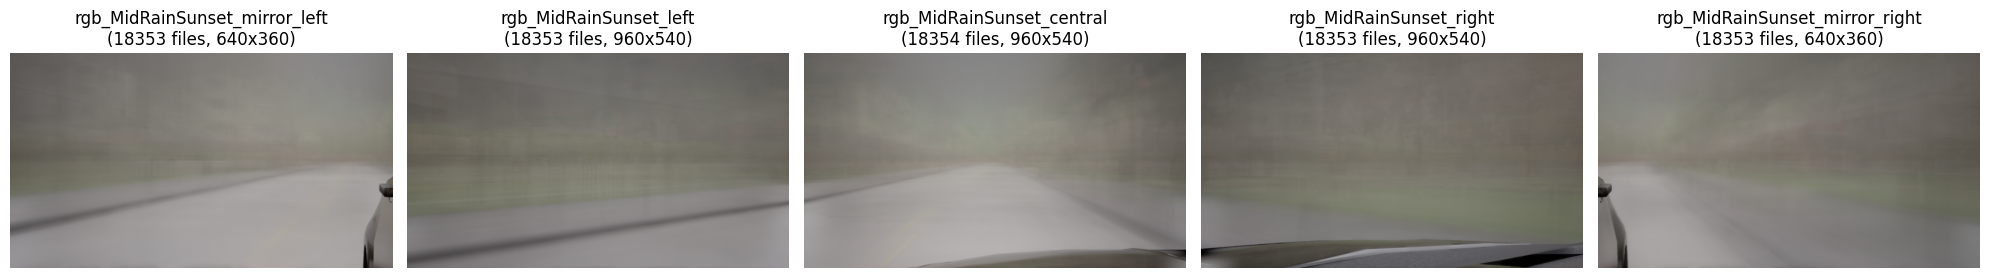

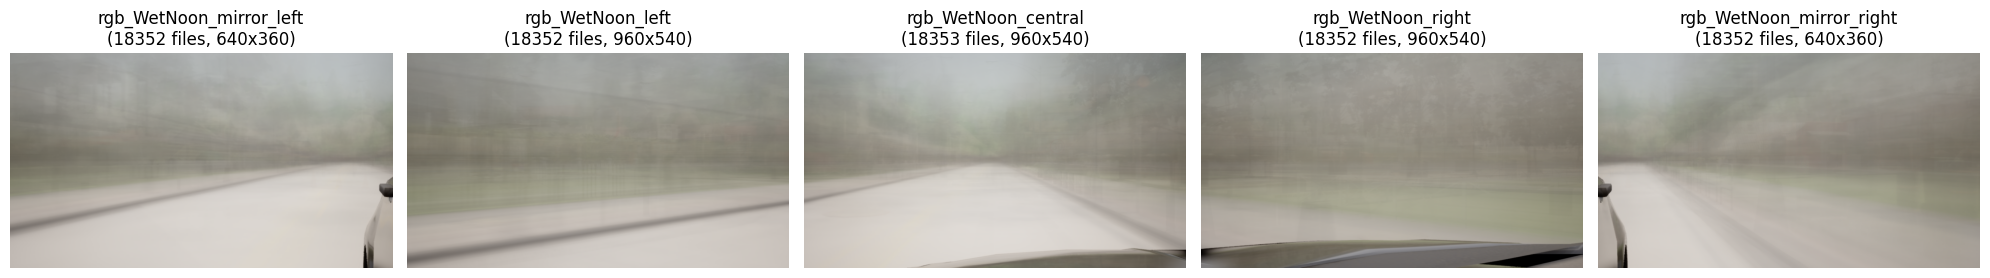

In [29]:
weather_list = ['ClearSunset', 'CloudyNoon', 'HardRainNoon', 'MidRainSunset', 'WetNoon']

for weather in weather_list:
    file_types_to_plot = [f'rgb_{weather}_mirror_left', f'rgb_{weather}_left', f'rgb_{weather}_central', f'rgb_{weather}_right', f'rgb_{weather}_mirror_right']
    plot_average_images(output_dir, file_types_to_plot)

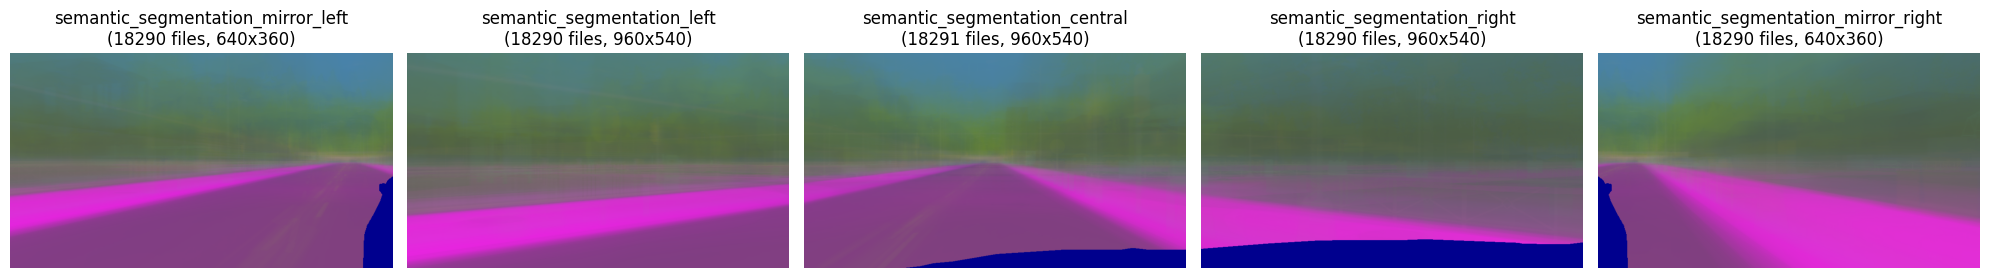

In [27]:
file_types_to_plot = ['semantic_segmentation_mirror_left', 'semantic_segmentation_left', 'semantic_segmentation_central',
                      'semantic_segmentation_right', 'semantic_segmentation_mirror_right']
plot_average_images(output_dir, file_types_to_plot)